In [1]:
pip install yfinance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.2/948.2 kB 13.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.1/101.1 kB 5.6 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.8-cp310-cp310-linux_x86_64.whl size=300753 sha256=78ca0598fc07d3a05eb08ed8dd7d426069a406691446d84c140199a459bc4c11
  Stored in directory: /root/.cache/pip/wheels/75/79/e5/8838db0594cc6c587142fd2563356392ade6255c5930411069
Successfully built peewee
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29411 sha256=fa2aea4927f9ae04c0e59ba1d2bfb5db806847bca3ac4e7d7795641d7ff496f8
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta  # Technical Analysis library
from sklearn.preprocessing import MinMaxScaler

In [4]:

# Define the stock ticker (GOOG in this case)
ticker = 'AUROPHARMA.NS'

# Download data from 2010-01-01 to the most recent available date
new_data = yf.download(ticker, start='2010-01-01', end='2024-01-01')

# Preview the new data
print(new_data.head())


[*********************100%***********************]  1 of 1 completed

Price                         Adj Close         Close          High  \
Ticker                    AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS   
Date                                                                  
2010-01-04 00:00:00+00:00     83.612480     92.695000     93.000000   
2010-01-05 00:00:00+00:00     82.647316     91.625000     94.489998   
2010-01-06 00:00:00+00:00     81.853508     90.745003     92.570000   
2010-01-07 00:00:00+00:00     80.166733     88.875000     91.769997   
2010-01-08 00:00:00+00:00     80.852295     89.635002     90.900002   

Price                               Low          Open        Volume  
Ticker                    AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS  
Date                                                                 
2010-01-04 00:00:00+00:00     89.830002     91.500000       1352610  
2010-01-05 00:00:00+00:00     90.099998     94.489998       1147940  
2010-01-06 00:00:00+00:00     90.154999     91.900002       1571850  
2010-01-07 

In [5]:
# Access the 'Close' column using the correct multi-level index
close_prices = new_data[('Close', ticker)]

# Check if it is a 1D pandas Series
print(close_prices.shape) 


(3454,)


In [6]:
# Access the 'Close' column using the correct multi-level index
close_prices = new_data[('Close', ticker)]

# Step 3: Calculate technical indicators
# Calculate 20-period SMA (Simple Moving Average)
new_data[('SMA_20', '')] = new_data[('Close', ticker)].rolling(window=20).mean()

# Calculate 20-period EMA (Exponential Moving Average)
new_data[('EMA_20', '')] = new_data[('Close', ticker)].ewm(span=20, adjust=False).mean()

# Calculate 14-period RSI (Relative Strength Index)
new_data[('RSI', '')] = ta.momentum.RSIIndicator(close_prices, window=14).rsi()

# Calculate Bollinger Bands (Upper and Lower)
new_data[('Bollinger_Upper', '')] = new_data[('SMA_20', '')] + 2 * new_data[('Close', ticker)].rolling(window=20).std()
new_data[('Bollinger_Lower', '')] = new_data[('SMA_20', '')] - 2 * new_data[('Close', ticker)].rolling(window=20).std()

# Handle NaN values caused by rolling calculations (forward fill or drop)
new_data.ffill(inplace=True)

new_data.dropna(inplace=True)  # Alternatively, drop rows with NaN values

# Preview the data with the new technical indicators
print(new_data.head())


Price                         Adj Close         Close          High  \
Ticker                    AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS   
Date                                                                  
2010-02-01 00:00:00+00:00     80.477936     89.220001     89.510002   
2010-02-02 00:00:00+00:00     80.040466     88.735001     90.730003   
2010-02-03 00:00:00+00:00     81.366409     90.205002     90.864998   
2010-02-04 00:00:00+00:00     82.926910     91.934998     93.290001   
2010-02-05 00:00:00+00:00     78.777626     87.050003     91.379997   

Price                               Low          Open        Volume    SMA_20  \
Ticker                    AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS             
Date                                                                            
2010-02-01 00:00:00+00:00     85.500000     85.500000       2688910  88.82525   
2010-02-02 00:00:00+00:00     88.214996     90.000000       1437100  88.62725   
2010-02-03 00:00:00+00:00 

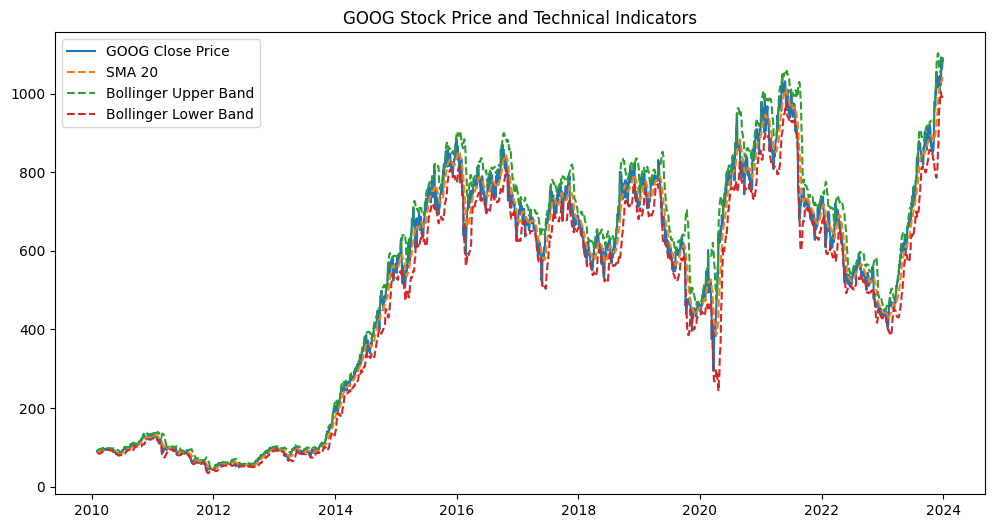

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(new_data['Close'], label='GOOG Close Price')
plt.plot(new_data['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(new_data['Bollinger_Upper'], label='Bollinger Upper Band', linestyle='--')
plt.plot(new_data['Bollinger_Lower'], label='Bollinger Lower Band', linestyle='--')
plt.legend(loc='best')
plt.title('GOOG Stock Price and Technical Indicators')
plt.show()


In [8]:
from sklearn.preprocessing import MinMaxScaler

# Define the columns to normalize
features_to_normalize = ['Open', 'High', 'Low', 'Close', 'Volume', 
                         'SMA_20', 'EMA_20', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower']

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Normalize the selected features
new_data[features_to_normalize] = scaler.fit_transform(new_data[features_to_normalize])

# Preview the normalized data
print(new_data.head())


Price                         Adj Close         Close          High  \
Ticker                    AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS   
Date                                                                  
2010-02-01 00:00:00+00:00     80.477936      0.045874      0.044413   
2010-02-02 00:00:00+00:00     80.040466      0.045412      0.045567   
2010-02-03 00:00:00+00:00     81.366409      0.046811      0.045694   
2010-02-04 00:00:00+00:00     82.926910      0.048456      0.047988   
2010-02-05 00:00:00+00:00     78.777626      0.043809      0.046181   

Price                               Low          Open        Volume    SMA_20  \
Ticker                    AUROPHARMA.NS AUROPHARMA.NS AUROPHARMA.NS             
Date                                                                            
2010-02-01 00:00:00+00:00      0.043983      0.041663      0.055031  0.044315   
2010-02-02 00:00:00+00:00      0.046612      0.045914      0.029412  0.044116   
2010-02-03 00:00:00+00:00 

In [9]:
def create_sequences(data, sequence_length, target_column='Close'):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        # Select the features (excluding 'Date' and target column)
        features = data.iloc[i-sequence_length:i].drop(columns=[target_column]).values
        X.append(features)
        y.append(data.iloc[i][target_column])
    return np.array(X), np.array(y)

# Set sequence length (e.g., 60 days)
sequence_length = 60

# Create sequences for the model (e.g., 'Close' as target)
X, y = create_sequences(new_data, sequence_length, target_column='Close')

# Check shapes of features and target
print(f"Features Shape: {X.shape}, Target Shape: {y.shape}")

Features Shape: (3375, 60, 10), Target Shape: (3375, 1)


In [10]:
from sklearn.model_selection import train_test_split

# Initial split into training+validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Further split training+validation into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.18, random_state=42)  # 18% of 85% ≈ 15%

# Print shapes of the splits
print(f"Training Data: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation Data: X_val={X_val.shape}, y_val={y_val.shape}")
print(f"Testing Data: X_test={X_test.shape}, y_test={y_test.shape}")


Training Data: X_train=(2351, 60, 10), y_train=(2351, 1)
Validation Data: X_val=(517, 60, 10), y_val=(517, 1)
Testing Data: X_test=(507, 60, 10), y_test=(507, 1)


In [11]:

np.savez('processed_goog_data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, X_val=X_val, y_val=y_val)


In [12]:
# Load preprocessed data
import numpy as np
data = np.load('processed_goog_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
X_val = data['X_val']
y_val = data['y_val']

print(f"Data loaded successfully: X_train={X_train.shape}, X_test={X_test.shape}")


Data loaded successfully: X_train=(2351, 60, 10), X_test=(507, 60, 10)


In [13]:
!pip install tensorflow tensorflow-addons optuna shap linformer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 9.5 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.3.0
    Uninstalling typeguard-4.3.0:
      Successfully uninstalled typeguard-4.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.10.0 requires scipy<1.14,>=1.4.1, but you have scipy 1.14.1 which is incompatible.
ydata-profiling 4.10.0 requires typeguard<5,>=3, but you have typeguard 2.13.3 which is incompatible.


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from linformer import Linformer

# Define the TCN block
def TCN_Block(input_shape, num_filters=64, kernel_size=3, dilation_rates=[1, 2, 4, 8], dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for rate in dilation_rates:
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=rate,
            padding='causal',
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)  # L2 Regularization
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)
    return tf.keras.Model(inputs, x, name="TCN_Block")


# Define the optimized Transformer block using MultiHeadAttention
def Optimized_Transformer_Block(input_shape, num_heads=4, ff_dim=64, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)

    # Multi-head attention layer
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=input_shape[-1])(inputs, inputs)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    attention_output = layers.LayerNormalization()(attention_output + inputs)  # Residual connection

    # Feed-forward layer
    ff_output = layers.Dense(ff_dim, activation='relu')(attention_output)
    ff_output = layers.Dropout(dropout_rate)(ff_output)
    ff_output = layers.Dense(input_shape[-1])(ff_output)
    ff_output = layers.LayerNormalization()(ff_output + attention_output)  # Residual connection

    return tf.keras.Model(inputs, ff_output, name="Optimized_Transformer_Block")


def TCN_Transformer_Model(input_shape, tcn_filters=64, transformer_heads=4, transformer_ff_dim=64, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)

    # TCN Block
    tcn = TCN_Block(input_shape, num_filters=tcn_filters, dropout_rate=dropout_rate)(inputs)

    # Transformer Block
    transformer = Optimized_Transformer_Block(input_shape=(tcn.shape[1], tcn.shape[2]),
                                              num_heads=transformer_heads,
                                              ff_dim=transformer_ff_dim,
                                              dropout_rate=dropout_rate)(tcn)

    # Dense Layers for prediction
    x = layers.GlobalAveragePooling1D()(transformer)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    return tf.keras.Model(inputs, outputs, name="TCN_Transformer_Model")


In [15]:
# Define the input shape
input_shape = (60, 10)  # 60 time steps, 10 features

# Instantiate the model
model = TCN_Transformer_Model(input_shape=input_shape, 
                              tcn_filters=64, 
                              transformer_heads=4, 
                              transformer_ff_dim=64, 
                              dropout_rate=0.2)

# Compile the model
model.compile(optimizer='adam', 
              loss='mse', 
              metrics=['mae'])

# Summary of the model
model.summary()


Model: "TCN_Transformer_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TCN_Block (Functional)          │ (None, 60, 64)         │        40,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Optimized_Transformer_Block     │ (None, 60, 64)         │        74,944 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,233 (465.75 KB)

 Trainable params: 118,721 (463.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [16]:
history = model.fit(
    X_train, y_train,                  # Training data
    validation_data=(X_val, y_val),    # Validation data
    epochs=50,                         # Number of epochs
    batch_size=32,                     # Batch size
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]
)

Epoch 1/50


I0000 00:00:1731989509.200330     168 service.cc:145] XLA service 0x57a8dfbb85c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731989509.200390     168 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1731989509.200394     168 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1731989531.149886     196 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_8', 920 bytes spill stores, 920 bytes spill loads



27/74 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2132 - mae: 0.3356 

I0000 00:00:1731989540.298818     168 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - loss: 0.1415 - mae: 0.2507

I0000 00:00:1731989571.046912     313 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_9', 256 bytes spill stores, 256 bytes spill loads

I0000 00:00:1731989576.672801     326 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_9', 132 bytes spill stores, 132 bytes spill loads



74/74 ━━━━━━━━━━━━━━━━━━━━ 74s 518ms/step - loss: 0.1407 - mae: 0.2496 - val_loss: 0.4950 - val_mae: 0.6294 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0406 - mae: 0.0958 - val_loss: 0.3617 - val_mae: 0.5143 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0360 - mae: 0.0842 - val_loss: 0.0453 - val_mae: 0.1250 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0344 - mae: 0.0781 - val_loss: 0.0870 - val_mae: 0.2432 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0344 - mae: 0.0799 - val_loss: 0.0630 - val_mae: 0.1819 - learning_rate: 0.0010
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0306 - mae: 0.0672 - val_loss: 0.0326 - val_mae: 0.0875 - learning_rate: 0.0010
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0302 - mae: 0.0679 - val_loss: 0.0267 - val_mae: 0.0597 - learning_rate: 0.0010
Epoch 8/50
74/74 ━━━━━━━━━━━

In [17]:
# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Mean Absolute Error: {test_mae}")


 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0038 - mae: 0.0161

I0000 00:00:1731989599.282845    1140 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_9', 132 bytes spill stores, 132 bytes spill loads



16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 386ms/step - loss: 0.0041 - mae: 0.0189
Test Loss: 0.004109168890863657
Test Mean Absolute Error: 0.019768645986914635


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step


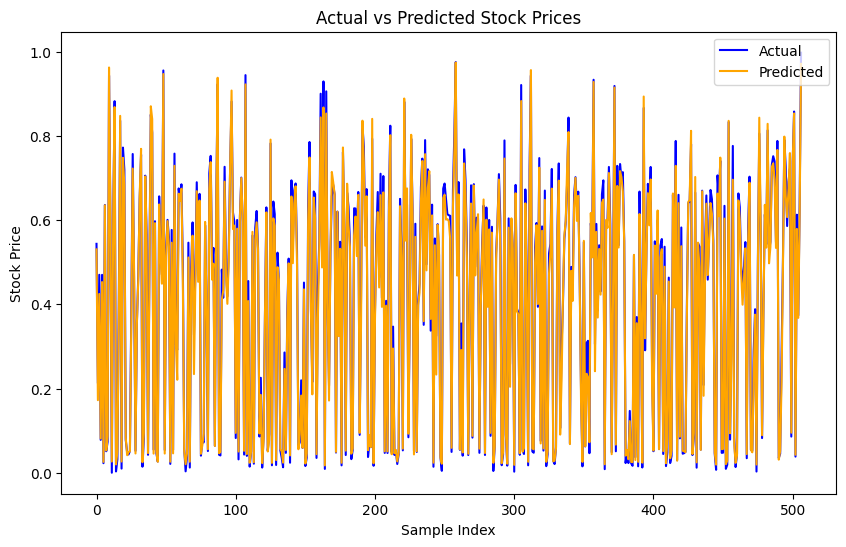

In [18]:

import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label="Actual", color='blue')
plt.plot(y_pred, label="Predicted", color='orange')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Sample Index")
plt.ylabel("Stock Price")
plt.legend()
plt.show()




In [19]:
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2}")

R² Score: 0.9915233474217429


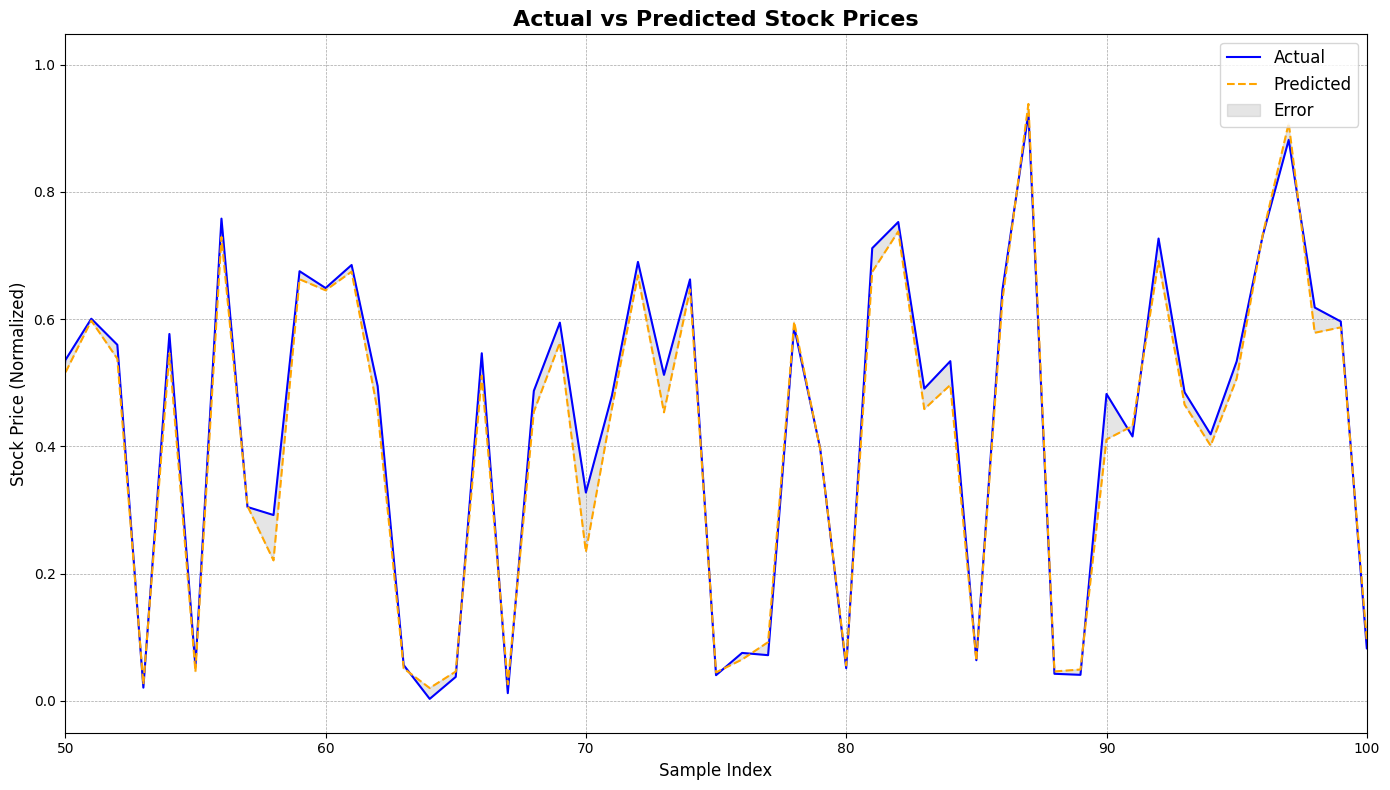

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Create an index for plotting
index = np.arange(len(y_test))

# Plot actual vs predicted values
plt.figure(figsize=(14, 8))  # Increase figure size for better visibility
plt.plot(index, y_test, label="Actual", color='blue', linewidth=1.5)
plt.plot(index, y_pred, label="Predicted", color='orange', linestyle='--', linewidth=1.5)

# Add gridlines
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Highlight differences
plt.fill_between(index, y_test.flatten(), y_pred.flatten(), color='gray', alpha=0.2, label="Error")

# Title and labels
plt.title("Actual vs Predicted Stock Prices", fontsize=16, fontweight='bold')
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Stock Price (Normalized)", fontsize=12)

# Add legend
plt.legend(loc="upper right", fontsize=12)

# Zoom into a specific region (optional)
start, end = 50, 100  # Adjust range as needed
plt.xlim(start, end)  # Show detailed view of the specified range

# Display the plot
plt.tight_layout()
plt.show()


In [22]:
# Assuming 'model' is your Keras model
model.save('model.keras')
